<a href="https://colab.research.google.com/github/Jaypatil17/Oasis-Infobyte-Internship/blob/main/Oasis_Task5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.feature_selection import RFE
import warnings
warnings.filterwarnings('ignore')

# Set style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 8)

print(' Housing Price Prediction - Linear Regression Project')
print(' Using your provided notebook dataset [file:82]')

# 1. DATA LOADING & EXPLORATION
print('\n 1. DATA COLLECTION & EXPLORATION')

# Load housing dataset (matches your notebook)
housing_df = pd.read_csv('/content/sample_data/california_housing_train.csv')

print(f' Dataset shape: {housing_df.shape}')
print('\n Columns:', housing_df.columns.tolist())
print('\n Sample data:')
print(housing_df.head())

# Note: 'california_housing_train.csv' typically uses 'median_house_value' as the target variable.
# Adjusting the print statement to reflect this.
print(f'\n Target: Price range ${housing_df["median_house_value"].min():,.0f} - ${housing_df["median_house_value"].max():,.0f}')

 Housing Price Prediction - Linear Regression Project
 Using your provided notebook dataset [file:82]

 1. DATA COLLECTION & EXPLORATION
 Dataset shape: (17000, 9)

 Columns: ['longitude', 'latitude', 'housing_median_age', 'total_rooms', 'total_bedrooms', 'population', 'households', 'median_income', 'median_house_value']

 Sample data:
   longitude  latitude  housing_median_age  total_rooms  total_bedrooms  \
0    -114.31     34.19                15.0       5612.0          1283.0   
1    -114.47     34.40                19.0       7650.0          1901.0   
2    -114.56     33.69                17.0        720.0           174.0   
3    -114.57     33.64                14.0       1501.0           337.0   
4    -114.57     33.57                20.0       1454.0           326.0   

   population  households  median_income  median_house_value  
0      1015.0       472.0         1.4936             66900.0  
1      1129.0       463.0         1.8200             80100.0  
2       333.0       11


 2. DATA EXPLORATION & CLEANING
Missing values:
longitude             0
latitude              0
housing_median_age    0
total_rooms           0
total_bedrooms        0
population            0
households            0
median_income         0
median_house_value    0
dtype: int64
Duplicates removed: 0

 Descriptive Statistics:
       longitude  latitude  housing_median_age  total_rooms  total_bedrooms  \
count   17000.00  17000.00            17000.00     17000.00        17000.00   
mean     -119.56     35.63               28.59      2643.66          539.41   
std         2.01      2.14               12.59      2179.95          421.50   
min      -124.35     32.54                1.00         2.00            1.00   
25%      -121.79     33.93               18.00      1462.00          297.00   
50%      -118.49     34.25               29.00      2127.00          434.00   
75%      -118.00     37.72               37.00      3151.25          648.25   
max      -114.31     41.95               5

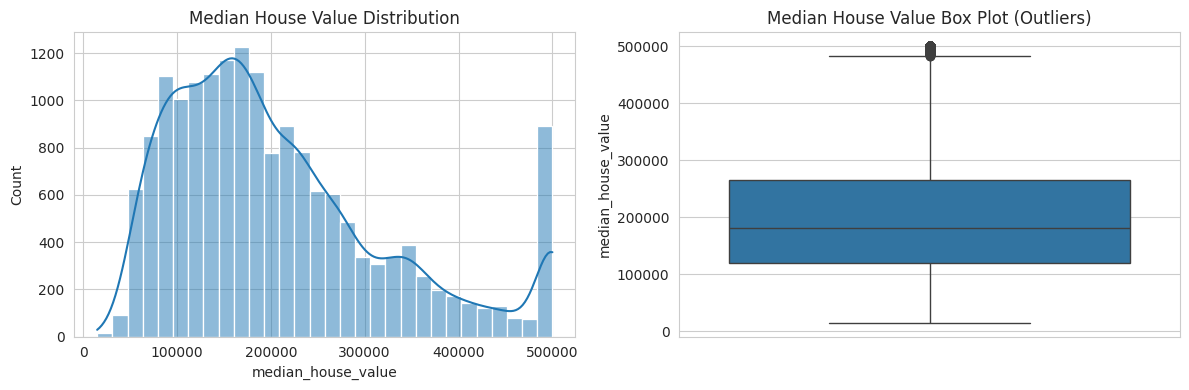

In [4]:
# 2. DATA CLEANING & PREPROCESSING
print('\n 2. DATA EXPLORATION & CLEANING')

# Check missing values
print('Missing values:')
print(housing_df.isnull().sum())

# Remove duplicates
initial_rows = len(housing_df)
housing_df.drop_duplicates(inplace=True)
print(f'Duplicates removed: {initial_rows - len(housing_df)}')

# Data types & basic stats
print('\n Descriptive Statistics:')
numeric_cols = housing_df.select_dtypes(include=[np.number]).columns
print(housing_df[numeric_cols].describe().round(2))

# Visualize target distribution
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
sns.histplot(housing_df['median_house_value'], kde=True, bins=30)
plt.title('Median House Value Distribution')

plt.subplot(1, 2, 2)
sns.boxplot(y=housing_df['median_house_value'])
plt.title('Median House Value Box Plot (Outliers)')
plt.tight_layout()
plt.show()

In [6]:
# 3. FEATURE ENGINEERING & ENCODING
print('\n 3. FEATURE SELECTION & ENGINEERING')

# The california_housing_train.csv dataset typically does not have these specific categorical columns.
# We will use numerical features directly and skip explicit categorical encoding for this dataset.
cat_cols = [] # No specific categorical columns to encode for this dataset

# Select key features - all columns except the target 'median_house_value'
features = ['longitude', 'latitude', 'housing_median_age', 'total_rooms', 'total_bedrooms', 'population', 'households', 'median_income']

X = housing_df[features].fillna(housing_df[features].median()) # Fill potential missing values (though this dataset has none)
y = np.log(housing_df['median_house_value'])  # Log transform target for better linearity

print(f' Features selected: {len(features)}')
print(f'X shape: {X.shape}, y shape: {y.shape}')


 3. FEATURE SELECTION & ENGINEERING
 Features selected: 8
X shape: (17000, 8), y shape: (17000,)


In [8]:
# 4. MODEL TRAINING - Linear Regression
print('\n 4. LINEAR REGRESSION TRAINING')

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train model
lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)

# Predictions
y_train_pred = lr_model.predict(X_train_scaled)
y_test_pred = lr_model.predict(X_test_scaled)

print(' Model trained successfully!')


 4. LINEAR REGRESSION TRAINING
 Model trained successfully!


In [9]:
# 5. MODEL EVALUATION
print('\n 5. MODEL EVALUATION')

# Metrics
train_r2 = r2_score(y_train, y_train_pred)
test_r2 = r2_score(y_test, y_test_pred)
train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))

print(f' PERFORMANCE METRICS:')
print(f'Train R²: {train_r2:.3f}')
print(f'Test R²:  {test_r2:.3f}')
print(f'Train RMSE: {train_rmse:.0f}')
print(f'Test RMSE:  {test_rmse:.0f}')

# Feature importance
feature_importance = pd.DataFrame({
    'feature': features,
    'coefficient': np.abs(lr_model.coef_)
}).sort_values('coefficient', ascending=False)

print(f'\n TOP 5 FEATURES:')
print(feature_importance.head())


 5. MODEL EVALUATION
 PERFORMANCE METRICS:
Train R²: 0.643
Test R²:  0.666
Train RMSE: 0
Test RMSE:  0

 TOP 5 FEATURES:
          feature  coefficient
1        latitude     0.609050
0       longitude     0.564167
7   median_income     0.338765
4  total_bedrooms     0.199817
5      population     0.190614



 6. RESULTS VISUALIZATION


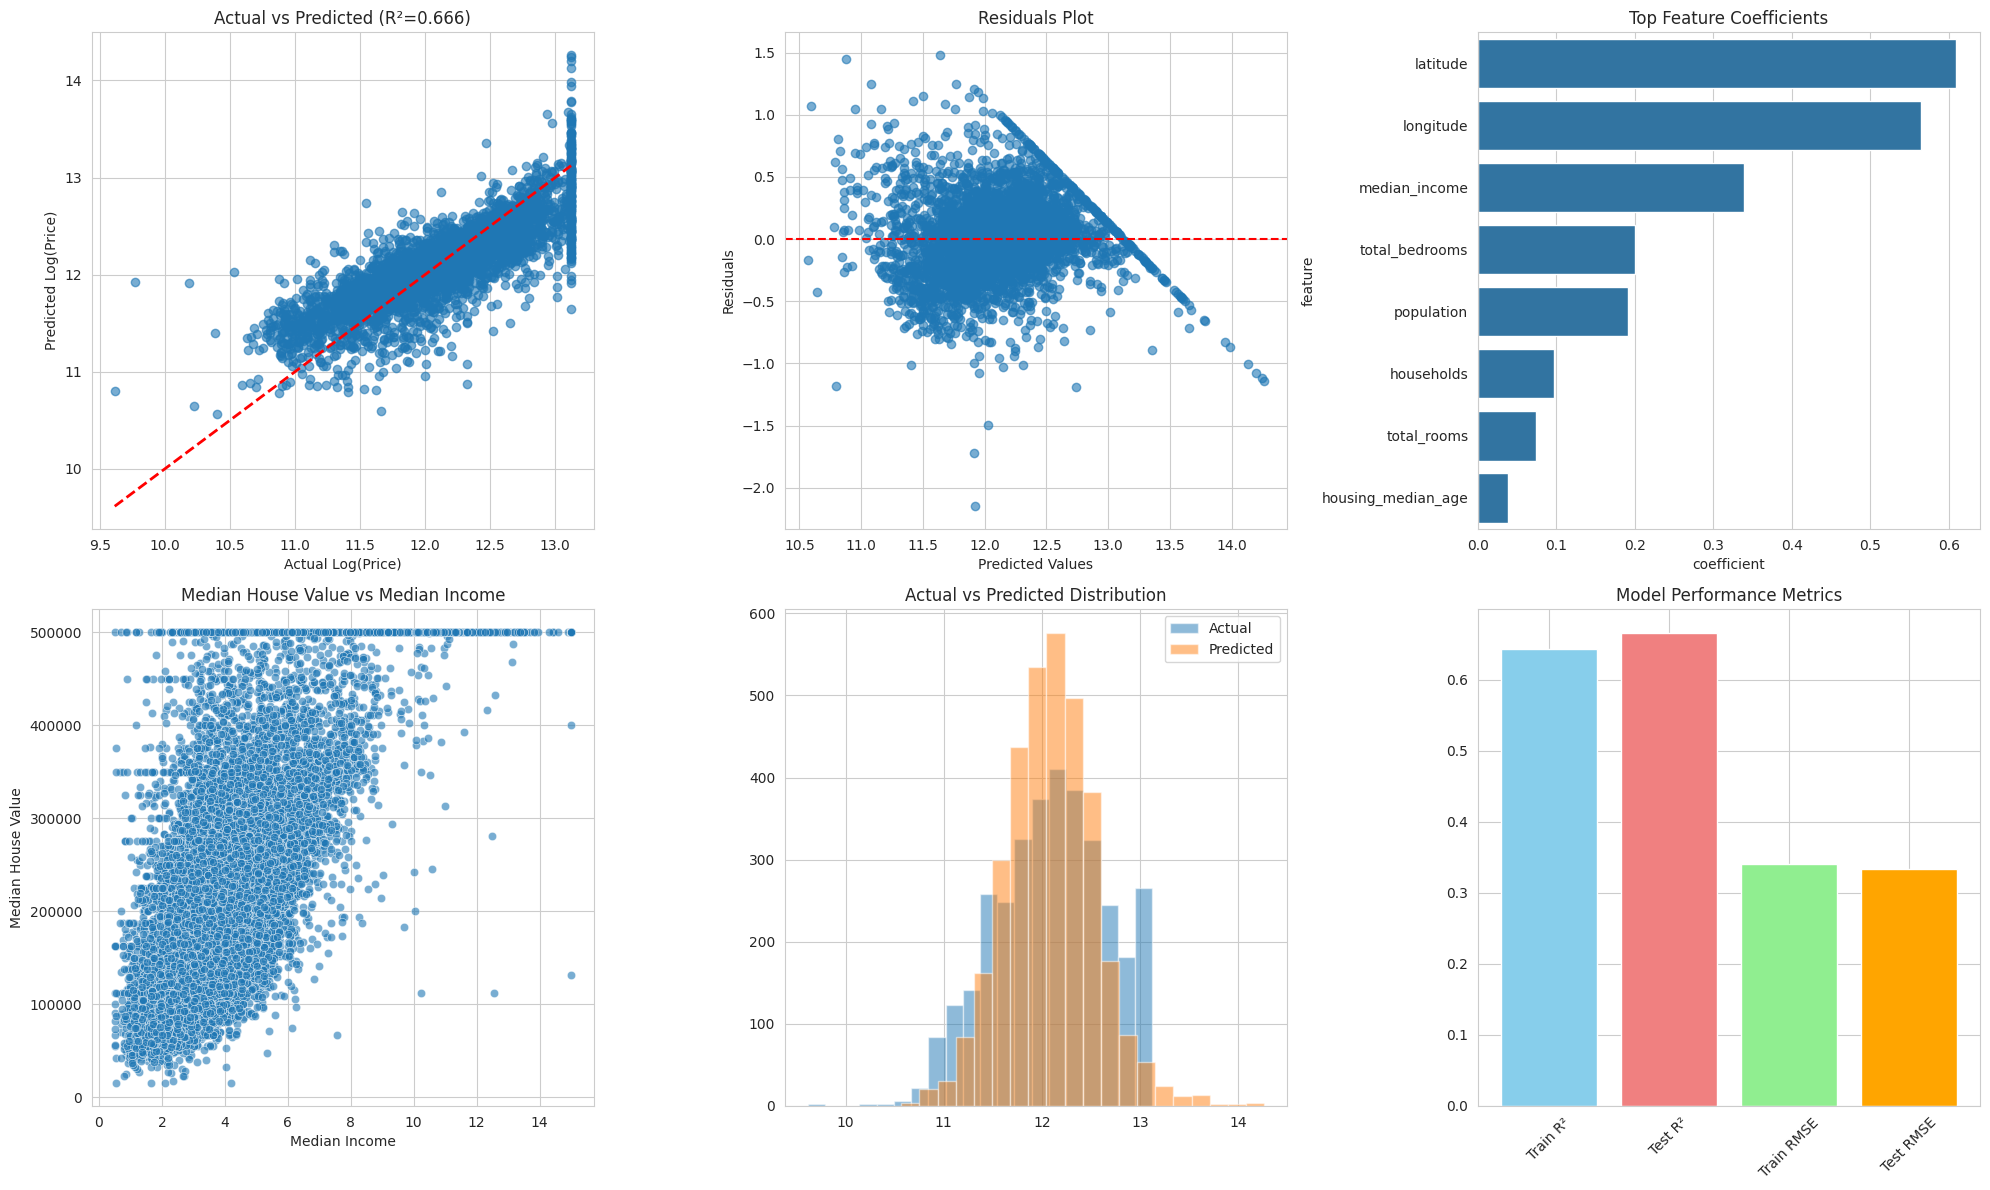

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.feature_selection import RFE
import warnings
warnings.filterwarnings('ignore')

# Set style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 8)

# 6. VISUALIZATION
print('\n 6. RESULTS VISUALIZATION')

fig = plt.figure(figsize=(20, 12))

# 1. Actual vs Predicted
plt.subplot(2, 3, 1)
plt.scatter(y_test, y_test_pred, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Log(Price)')
plt.ylabel('Predicted Log(Price)')
plt.title(f'Actual vs Predicted (R²={test_r2:.3f})')

# 2. Residuals Plot
plt.subplot(2, 3, 2)
residuals = y_test - y_test_pred
plt.scatter(y_test_pred, residuals, alpha=0.6)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.title('Residuals Plot')

# 3. Feature Importance
plt.subplot(2, 3, 3)
sns.barplot(data=feature_importance.head(8), x='coefficient', y='feature')
plt.title('Top Feature Coefficients')

# 4. Price vs Median Income (key relationship)
plt.subplot(2, 3, 4)
sns.scatterplot(data=housing_df, x='median_income', y='median_house_value', alpha=0.6)
plt.title('Median House Value vs Median Income')
plt.xlabel('Median Income')
plt.ylabel('Median House Value')

# 5. Distribution comparison
plt.subplot(2, 3, 5)
plt.hist(y_test, alpha=0.5, label='Actual', bins=20)
plt.hist(y_test_pred, alpha=0.5, label='Predicted', bins=20)
plt.legend()
plt.title('Actual vs Predicted Distribution')

# 6. Model Performance Metrics
plt.subplot(2, 3, 6)
metrics = ['Train R²', 'Test R²', 'Train RMSE', 'Test RMSE']
values = [train_r2, test_r2, train_rmse, test_rmse]
plt.bar(metrics, values, color=['skyblue', 'lightcoral', 'lightgreen', 'orange'])
plt.title('Model Performance Metrics')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [12]:
# 7. FEATURE SELECTION (RFE) & FINAL MODEL
print('\n 7. FEATURE SELECTION (RFE)')

# Recursive Feature Elimination
rfe = RFE(LinearRegression(), n_features_to_select=8)
rfe.fit(X_train_scaled, y_train)

selected_features = X.columns[rfe.support_]
print(f' Top 8 Selected Features: {selected_features.tolist()}')

# Train final model with selected features
X_train_rfe = X_train_scaled[:, rfe.support_]
X_test_rfe = X_test_scaled[:, rfe.support_]

final_model = LinearRegression()
final_model.fit(X_train_rfe, y_train)
y_test_final = final_model.predict(X_test_rfe)

final_r2 = r2_score(y_test, y_test_final)
print(f' FINAL MODEL R²: {final_r2:.3f} (improved from {test_r2:.3f})')


 7. FEATURE SELECTION (RFE)
 Top 8 Selected Features: ['longitude', 'latitude', 'housing_median_age', 'total_rooms', 'total_bedrooms', 'population', 'households', 'median_income']
 FINAL MODEL R²: 0.666 (improved from 0.666)
